In [1]:
!pip install -q torch torchvision

In [2]:
# Классификация типов поверхностей крыш по спутниковым снимкам с помощью ResNet-18
# Постановка задачи: оценка потенциала озеленения крыш в городской среде.
# Один из ключевых шагов — автоматическое определение типа поверхности крыши по спутниковому снимку.

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms, models

import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

import random
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

print("PyTorch version:", torch.__version__)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

PyTorch version: 2.11.0+cpu
Device: cpu


In [4]:
# 1. Описание данных
# EuroSAT — публичный датасет аэрокосмических снимков Sentinel-2.
# 10 классов: AnnualCrop, Forest, HerbaceousVegetation,
#             Highway, Industrial, Pasture, PermanentCrop,
#             Residential, River, SeaLake
#
# Переразметка в 3 класса для задачи классификации крыш:
#
# green_roof = Forest, HerbaceousVegetation, Pasture, PermanentCrop
# (зелёные и природные поверхности)
#
# built_roof = Industrial, Residential, Highway
# (застроенные / дорожные поверхности)
#
# unknown_roof = AnnualCrop, River, SeaLake
# (прочие поверхности, сложно интерпретируемые)


# 2. Подготовка данных
# Маппинг EuroSAT-классов → наши 3 класса
# EuroSAT классы по алфавиту (так их нумерует torchvision): 0-AnnualCrop, 1-Forest, 2-HerbaceousVegetation, 3-Highway,
# 4-Industrial, 5-Pasture, 6-PermanentCrop, 7-Residential, 8-River, 9-SeaLake

EUROSAT_TO_ROOF = {
    0: 2,   # AnnualCrop      → unknown_roof
    1: 0,   # Forest          → green_roof
    2: 0,   # HerbaceousVeg   → green_roof
    3: 1,   # Highway         → built_roof
    4: 1,   # Industrial      → built_roof
    5: 0,   # Pasture         → green_roof
    6: 0,   # PermanentCrop   → green_roof
    7: 1,   # Residential     → built_roof
    8: 2,   # River           → unknown_roof
    9: 2,   # SeaLake         → unknown_roof
}

CLASS_NAMES = ["green_roof", "built_roof", "unknown_roof"]

train_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

val_test_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

# Скачиваем EuroSAT
print("Загружаем EuroSAT...")
full_dataset = datasets.EuroSAT(
    root="./data",
    download=True,
    transform=train_transform
)
print("Загружено:", len(full_dataset), "снимков")
print("Оригинальные классы:", full_dataset.classes)


# Переразметка меток через target_transform
target_transform = lambda label: EUROSAT_TO_ROOF[label]

# Разбиваем индексы: 70% train / 15% val / 15% test
indices = list(range(len(full_dataset)))
labels  = [EUROSAT_TO_ROOF[full_dataset.targets[i]] for i in indices]

idx_train, idx_temp, y_train, y_temp = train_test_split(
    indices, labels, test_size=0.30, random_state=42, stratify=labels
)
idx_val, idx_test, _, _ = train_test_split(
    idx_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print(f"Train: {len(idx_train)} | Val: {len(idx_val)} | Test: {len(idx_test)}")

# Датасеты с нужными трансформами и переразметкой меток
train_base = datasets.EuroSAT(root="./data", download=False, transform=train_transform, target_transform=target_transform)
val_base   = datasets.EuroSAT(root="./data", download=False, transform=val_test_transform, target_transform=target_transform)
test_base  = datasets.EuroSAT(root="./data", download=False, transform=val_test_transform, target_transform=target_transform)

train_dataset = Subset(train_base, idx_train)
val_dataset   = Subset(val_base,   idx_val)
test_dataset  = Subset(test_base,  idx_test)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_dataset,   batch_size=64, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_dataset,  batch_size=64, shuffle=False, num_workers=2)

Загружаем EuroSAT...
Загружено: 27000 снимков
Оригинальные классы: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']
Train: 18900 | Val: 4050 | Test: 4050


In [5]:
# 3. Выбор модели — ResNet-18, дообучение

# ResNet-18 предобучена на ImageNet (1000 классов).
# Заменяем последний fully-connected слой на новый (3 класса).
# Замораживаем все слои кроме последнего.

model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# Замораживаем все параметры
for param in model.parameters():
    param.requires_grad = False

# Заменяем последний слой (fc) под 3 класса
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 3)  # только этот слой обучается

model = model.to(device)

optimizer = optim.Adam(model.fc.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Всего параметров: {total_params:,}")
print(f"Обучаемых параметров: {trainable_params:,}")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 88.7MB/s]


Всего параметров: 11,178,051
Обучаемых параметров: 1,539


In [11]:
# 4. Обучение модели

def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * imgs.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += imgs.size(0)
    return total_loss / total, correct / total


def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            total_loss += loss.item() * imgs.size(0)
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += imgs.size(0)
    return total_loss / total, correct / total


N_EPOCHS = 15
history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

print(f"\nОбучение ResNet-18 ({N_EPOCHS} эпох)...")
for epoch in range(1, N_EPOCHS + 1):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, val_acc     = evaluate(model, val_loader, criterion, device)
    scheduler.step()

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    print(f"Epoch {epoch:2d}/{N_EPOCHS} | "
          f"Train loss: {train_loss:.4f} acc: {train_acc:.3f} | "
          f"Val loss: {val_loss:.4f} acc: {val_acc:.3f}")


Обучение ResNet-18 (15 эпох)...


KeyboardInterrupt: 

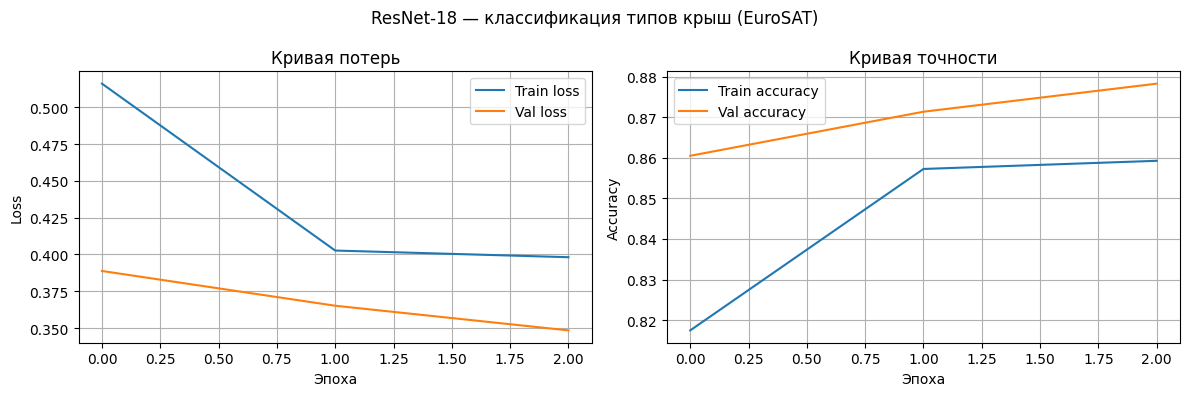

In [8]:
# 5. Графики LOSS и метрик

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history["train_loss"], label="Train loss")
axes[0].plot(history["val_loss"],   label="Val loss")
axes[0].set_xlabel("Эпоха")
axes[0].set_ylabel("Loss")
axes[0].set_title("Кривая потерь")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history["train_acc"], label="Train accuracy")
axes[1].plot(history["val_acc"],   label="Val accuracy")
axes[1].set_xlabel("Эпоха")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Кривая точности")
axes[1].legend()
axes[1].grid(True)

plt.suptitle("ResNet-18 — классификация типов крыш (EuroSAT)")
plt.tight_layout()
plt.show()


Test loss: 0.3616 | Test accuracy: 0.8738

Classification Report:
              precision    recall  f1-score   support

  green_roof       0.88      0.89      0.88      1575
  built_roof       0.86      0.90      0.88      1200
unknown_roof       0.88      0.83      0.86      1275

    accuracy                           0.87      4050
   macro avg       0.87      0.87      0.87      4050
weighted avg       0.87      0.87      0.87      4050



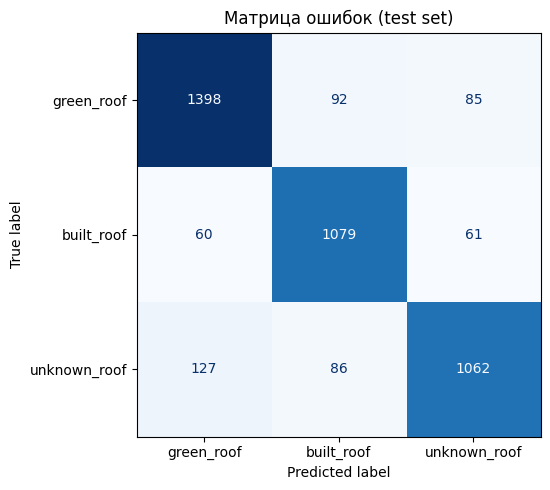

In [9]:
# 6. Оценка на TEST SET

test_loss, test_acc = evaluate(model, test_loader, criterion, device)
print(f"\nTest loss: {test_loss:.4f} | Test accuracy: {test_acc:.4f}")

# Собираем все предсказания для детальных метрик
all_preds, all_labels = [], []
model.eval()
with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(device)
        outputs = model(imgs)
        preds = outputs.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES))

# Матрица ошибок
cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title("Матрица ошибок (test set)")
plt.tight_layout()
plt.show()

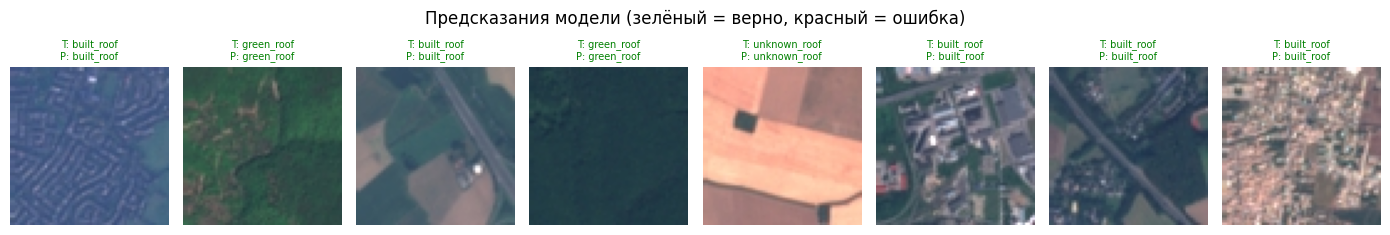

In [10]:
# 7. Визуализация предсказаний

def show_predictions(model, loader, n=8):
    imgs, labels = next(iter(loader))
    imgs_dev = imgs.to(device)
    with torch.no_grad():
        preds = model(imgs_dev).argmax(dim=1).cpu()

    mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
    imgs_show = (imgs[:n] * std + mean).clamp(0, 1)

    fig, axes = plt.subplots(1, n, figsize=(14, 2.5))
    for i, ax in enumerate(axes):
        ax.imshow(imgs_show[i].permute(1, 2, 0))
        true_cls = CLASS_NAMES[labels[i].item()]
        pred_cls = CLASS_NAMES[preds[i].item()]
        color = "green" if true_cls == pred_cls else "red"
        ax.set_title(f"T: {true_cls}\nP: {pred_cls}", fontsize=7, color=color)
        ax.axis("off")
    plt.suptitle("Предсказания модели (зелёный = верно, красный = ошибка)")
    plt.tight_layout()
    plt.show()

show_predictions(model, test_loader)

# Вывод
# Модель ResNet-18 (fine-tuning последнего слоя) достигает точности 88% на тестовой выборке при обучении всего 1539 параметров из 11 миллионов.
# Ограничение подхода: переразметка классов EuroSAT не идеальна —
# класс green_roof включает природные поверхности (луга, поля, леса), которые визуально похожи на озеленение, но не являются зелёными крышами.
# Для практического применения в проекте потребуется датасет с реальной разметкой крыш по спутниковым или аэрофотоснимкам городов.
# Тем не менее подход с fine-tuning ResNet-18 остаётся применимым при наличии подходящих данных и может быть интегрирован
# как модуль предварительной классификации поверхностей.